In [25]:
import seaborn as sns
import pandas as pd


df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [26]:
df.shape

(891, 15)

In [27]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [29]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [30]:
# Missing values as percentage
(df.isnull().sum() / len(df) * 100).round(2)

survived        0.00
pclass          0.00
sex             0.00
age            19.87
sibsp           0.00
parch           0.00
fare            0.00
embarked        0.22
class           0.00
who             0.00
adult_male      0.00
deck           77.22
embark_town     0.22
alive           0.00
alone           0.00
dtype: float64

In [31]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


/tmp/ipykernel_29489/3003242794.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="survived", data=df, palette=["coral", "steelblue"])


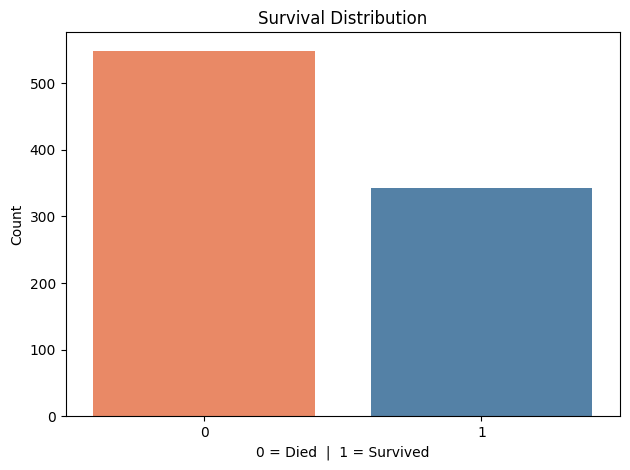

In [32]:
import matplotlib.pyplot as plt
sns.countplot(x="survived", data=df, palette=["coral", "steelblue"])
plt.title("Survival Distribution")
plt.xlabel("0 = Died  |  1 = Survived")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

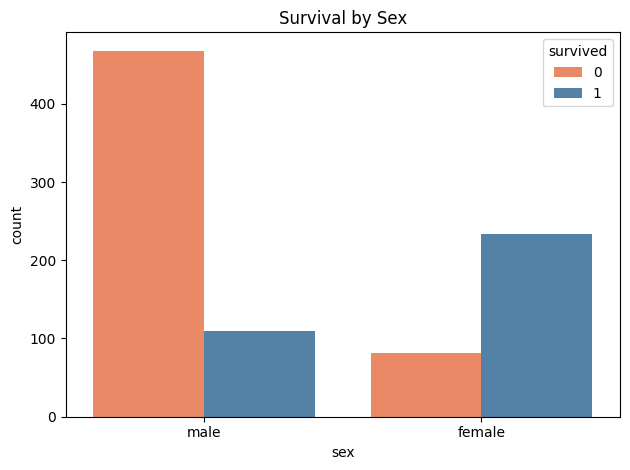

In [33]:
# survival by sex
sns.countplot(x="sex", hue="survived", data=df, palette=["coral", "steelblue"])
plt.title("Survival by Sex")
plt.tight_layout()
plt.show()

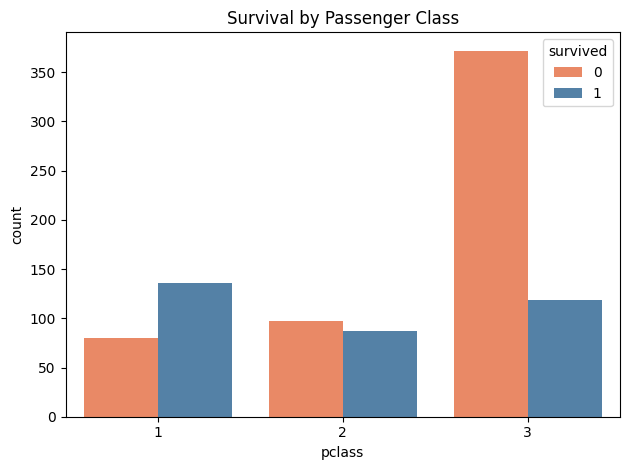

In [34]:
# survival by passenger class
sns.countplot(x="pclass", hue="survived", data=df, palette=["coral", "steelblue"])
plt.title("Survival by Passenger Class")
plt.tight_layout()
plt.show()

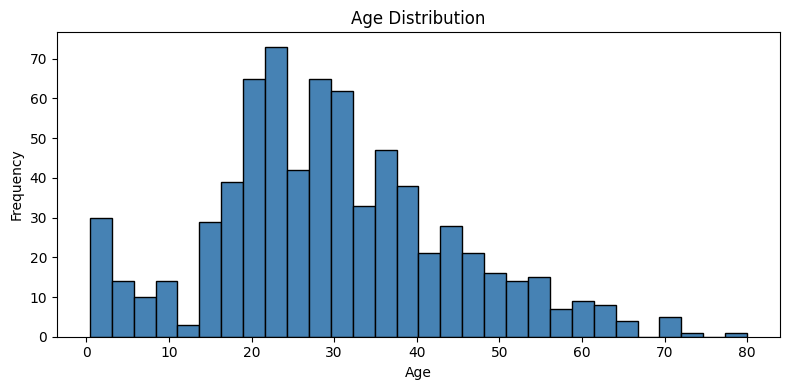

In [35]:
# age distribution
df["age"].plot(kind="hist", bins=30, color="steelblue", edgecolor="black", figsize=(8,4))
plt.title("Age Distribution")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

/tmp/ipykernel_29489/4290193417.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="survived", y="age", data=df, palette=["coral", "steelblue"])


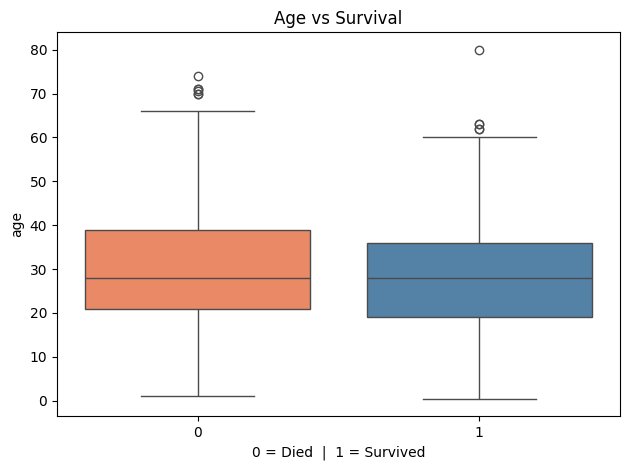

In [36]:
# age vs survival
sns.boxplot(x="survived", y="age", data=df, palette=["coral", "steelblue"])
plt.title("Age vs Survival")
plt.xlabel("0 = Died  |  1 = Survived")
plt.tight_layout()
plt.show()

____
# data Cleaning

___

In [37]:
df_clean = df.copy()

In [38]:
# drop columns that are useless or cause leakage
# class       →  duplicate of pclass
# who         →  derived from sex + age
# adult_male  →  derived from sex + age
# alive       →  data leakage (yes/no version of survived)
# embark_town →  duplicate of embarked
# deck        →  77% missing — too much to save

cols_to_drop = ["class", "who", "adult_male", "alive", "embark_town", "deck"]

df_clean.drop(cols_to_drop, axis=1, inplace=True)

print("Remaining columns:", df_clean.columns.tolist())
print("Shape:", df_clean.shape)

Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']
Shape: (891, 9)


In [39]:
# fix age — fill NaN with median
# median is better than mean for age because of outliers

df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

print("NaN in age:", df_clean["age"].isnull().sum())
print("Median age used:", df["age"].median())

NaN in age: 0
Median age used: 28.0


In [40]:

print("Embarked value counts:")
print(df_clean["embarked"].value_counts())

# mode = most frequent value
mode_embarked = df_clean["embarked"].mode()[0]
df_clean["embarked"] = df_clean["embarked"].fillna(mode_embarked)

print("\nNaN in embarked:", df_clean["embarked"].isnull().sum())
print("Mode used:", mode_embarked)

Embarked value counts:
embarked
S    644
C    168
Q     77
Name: count, dtype: int64

NaN in embarked: 0
Mode used: S


In [41]:
df_clean.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64

In [42]:
df_clean.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [43]:
# check current dtypes
df_clean.dtypes

survived      int64
pclass        int64
sex             str
age         float64
sibsp         int64
parch         int64
fare        float64
embarked        str
alone          bool
dtype: object

In [44]:
# fix alone  bool to int
# True → 1, False → 0

df_clean["alone"] = df_clean["alone"].astype("int8")

print("alone dtype:", df_clean["alone"].dtype)
print(df_clean["alone"].value_counts())

alone dtype: int8
alone
1    537
0    354
Name: count, dtype: int64


In [45]:
# fix age float to int
# age has no decimals — no need to store as float

df_clean["age"] = df_clean["age"].astype("int8")

print("age dtype:", df_clean["age"].dtype)

age dtype: int8


In [46]:
df_clean["sex"].unique()

<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str

In [47]:
# encode sex . Label Encoding
# male   → 0
# female → 1

df_clean["sex"] = df_clean["sex"].map({"male": 0, "female": 1})

print("sex dtype:", df_clean["sex"].dtype)
print(df_clean["sex"].value_counts())

sex dtype: int64
sex
0    577
1    314
Name: count, dtype: int64


In [48]:
# encode embarked  map to numeric
# S = Southampton → 0  (most common)
# C = Cherbourg   → 1
# Q = Queenstown  → 2

df_clean["embarked"] = df_clean["embarked"].map({"S": 0, "C": 1, "Q": 2})

print("embarked dtype:", df_clean["embarked"].dtype)
print(df_clean["embarked"].value_counts())

embarked dtype: int64
embarked
0    646
1    168
2     77
Name: count, dtype: int64


In [49]:
df_clean.dtypes

survived      int64
pclass        int64
sex           int64
age            int8
sibsp         int64
parch         int64
fare        float64
embarked      int64
alone          int8
dtype: object

In [50]:
df_clean.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,0,22,1,0,7.2500,0,0
1,1,1,1,38,1,0,71.2833,1,0
2,1,3,1,26,0,0,7.9250,0,1
3,1,1,1,35,1,0,53.1000,0,0
4,0,3,0,35,0,0,8.0500,0,1


In [64]:
col_to_change_type = ["survived", "pclass", "sex", "sibsp", "embarked"]

for col in col_to_change_type:
    df_clean[col] = df_clean[col].astype("int8")


In [65]:
df_clean.info()  # above error is because sex is str and we are changing type

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int8   
 1   pclass    891 non-null    int8   
 2   sex       891 non-null    int8   
 3   age       891 non-null    int8   
 4   sibsp     891 non-null    int8   
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    int8   
 8   alone     891 non-null    int8   
dtypes: float64(1), int64(1), int8(7)
memory usage: 20.1 KB


___

# Fwatuew Engineerng
___


In [66]:
#family_size
# how many people travelled together including themselves
# sibsp = siblings + spouses
# parch = parents + children
# + 1 for the passenger themselves

df_clean["family_size"] = df_clean["sibsp"] + df_clean["parch"] + 1

df_clean[["sibsp", "parch", "family_size"]].head()

,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [67]:
# families shared tickets  divide fare by family size
# gives a better measure of actual wealth per person

df_clean["fare_per_person"] = (df_clean["fare"] / df_clean["family_size"]).round(2)

df_clean[["fare", "family_size", "fare_per_person"]].head()

,fare,family_size,fare_per_person
0,7.2500,2,3.62
1,71.2833,2,35.64
2,7.9250,1,7.92
3,53.1000,2,26.55
4,8.0500,1,8.05


In [68]:
# passenger travelling completely alone
# alone col already exists but recalculate from family_size for consistency

df_clean["is_solo"] = (df_clean["family_size"] == 1).astype(int)

df_clean[["family_size", "alone", "is_solo"]].head(10)
# alone and is_solo should match exactly

,family_size,alone,is_solo
0,2,0,0
1,2,0,0
2,1,1,1
3,2,0,0
4,1,1,1
5,1,1,1
6,1,1,1
7,5,0,0
8,3,0,0
9,2,0,0


In [69]:
# drop alone col now — captured by is_solo and family_size
# drop sibsp and parch — captured by family_size

df_clean.drop(["sibsp", "parch", "alone"], axis=1, inplace=True)

print("Shape after dropping:", df_clean.shape)
print("Columns:", df_clean.columns.tolist())

Shape after dropping: (891, 9)
Columns: ['survived', 'pclass', 'sex', 'age', 'fare', 'embarked', 'family_size', 'fare_per_person', 'is_solo']


In [70]:
df_clean.isnull().sum()

survived           0
pclass             0
sex                0
age                0
fare               0
embarked           0
family_size        0
fare_per_person    0
is_solo            0
dtype: int64

In [71]:
df_clean.corr()

,survived,pclass,sex,age,fare,embarked,family_size,fare_per_person,is_solo
survived,1.000000,-0.338481,0.543351,-0.064909,0.257307,0.106811,0.016639,0.221598,-0.203367
pclass,-0.338481,1.000000,-0.131900,-0.339999,-0.549500,0.045702,0.065997,-0.485078,0.135207
sex,0.543351,-0.131900,1.000000,-0.080750,0.182333,0.116569,0.200988,0.115141,-0.303646
age,-0.064909,-0.339999,-0.080750,1.000000,0.096838,-0.009539,-0.245593,0.144563,0.171807
fare,0.257307,-0.549500,0.182333,0.096838,1.000000,0.062142,0.217138,0.840992,-0.271832
embarked,0.106811,0.045702,0.116569,-0.009539,0.062142,1.000000,-0.080281,0.082028,0.017807
family_size,0.016639,0.065997,0.200988,-0.245593,0.217138,-0.080281,1.000000,-0.099183,-0.690922
fare_per_person,0.221598,-0.485078,0.115141,0.144563,0.840992,0.082028,-0.099183,1.000000,0.045608
is_solo,-0.203367,0.135207,-0.303646,0.171807,-0.271832,0.017807,-0.690922,0.045608,1.000000


<Axes: >

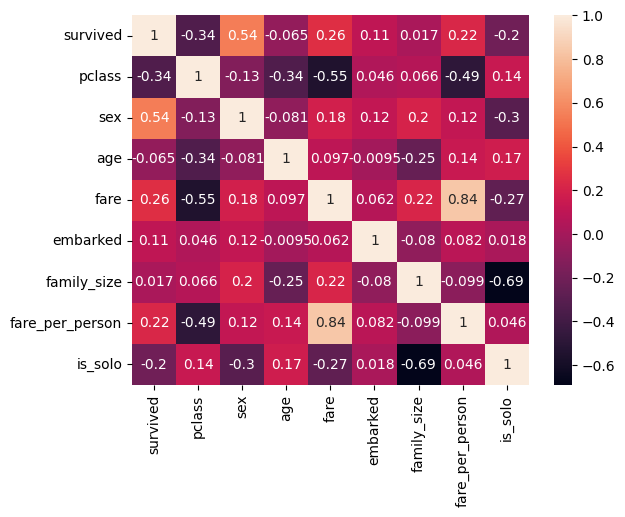

In [72]:
sns.heatmap(df_clean.corr(), annot=True)